### 15/05/26
There seem to be several issues with the fit-testing functions in analysislib.py, so I will test and tweak them in this Jupyter notebook

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, exponnorm, beta, gamma, landau, anderson, anderson_ksamp, chisquare, kstest, chi2
from analysislib import pdf2cdf

In [3]:
# Old fit-testing functions

def kolmogorov_smirnov(data, fit_cdf):
   '''
   Performs a Kolmogorov-Smirnov test to compare the empirical distribution of the data with the fitted distribution.
   Returns the KS statistic and p-value.
   '''
   ret = kstest(data, lambda x: fit_cdf(x))
   return ret.statistic, ret.pvalue

# anderson_darling does not seem to be working properly, likely due to the fact that anderson is 
# designed for testing against specific distributions rather than arbitrary fitted CDFs and 
# anderson_ksamp is designed for testing whether two samples come from the same distribution rather
#  than testing a sample against a fitted CDF. 
def anderson_darling(data, fit_cdf):
   '''
   Performs an Anderson-Darling test to compare the empirical distribution of the data with the fitted distribution.
   Returns the AD statistic and critical values.
   '''
   ret = anderson_ksamp([data, fit_cdf(np.sort(data))])
   # ret = anderson(data, dist=lambda x: fit_cdf(x)) # Does not work because dist must be one of the predefined distributions in scipy
   return ret.statistic, ret.pvalue

def chi_squared(data, fit_cdf, n_params=None):
   '''
   Performs a Chi-Squared test to compare the empirical distribution of the data with the fitted distribution.
   Returns the Chi-Squared statistic and p-value.
   '''
   n, bins = np.histogram(data, bins="fd", density=False)
   if n_params is None:
      n_params = len(fit_cdf.__code__.co_varnames) - 1 # Double check these make sense
   print(f"Number of parameters: {n_params}")
   expected_probs = fit_cdf(bins[1:]) - fit_cdf(bins[:-1])
   expected_probs /= np.sum(expected_probs) # Normalize
   expected = np.sum(n) * expected_probs
   # print(np.sum(n),np.sum(expected),np.sum(expected_probs))

   ret = chisquare(n,f_exp=expected,ddof=n_params)
   return ret.statistic, ret.pvalue


### Generate Random Testing Data Sets

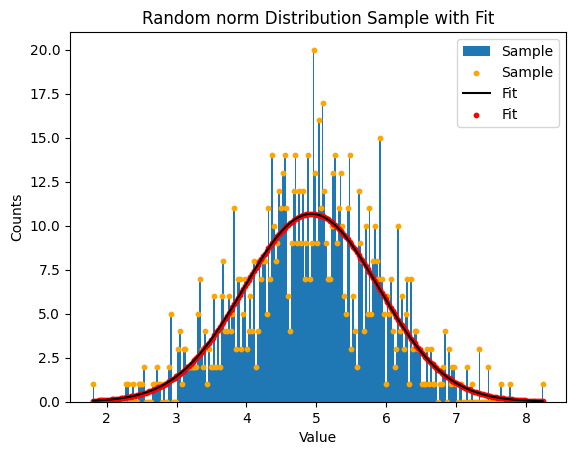

Original parameters: {'loc': 5, 'scale': 1}
Fit parameters: (np.float64(4.929497809346437), np.float64(0.9643761846163603))


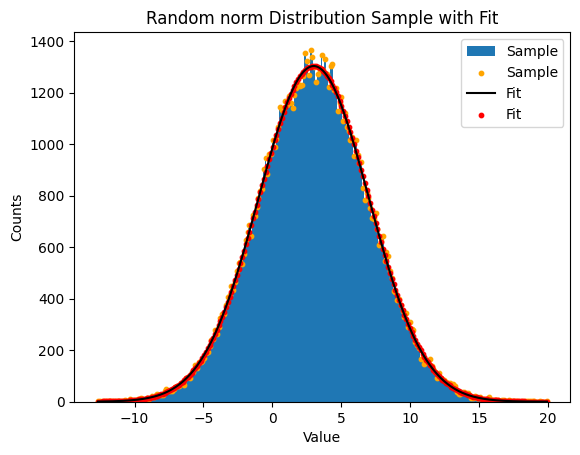

Original parameters: {'loc': 3, 'scale': 4}
Fit parameters: (np.float64(2.9962338311139214), np.float64(4.00468064157351))


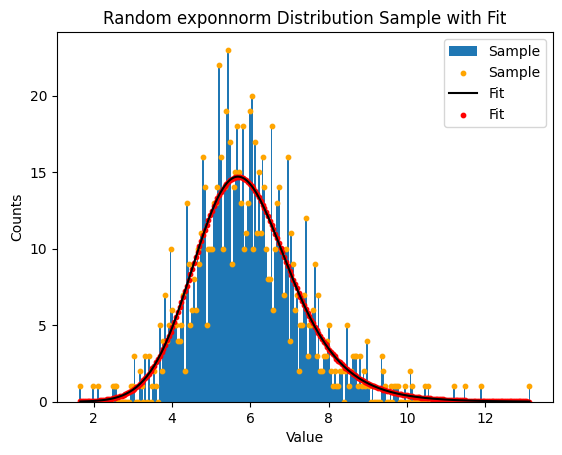

Original parameters: {'K': 1, 'loc': 5, 'scale': 1}
Fit parameters: (np.float64(0.9178109335041635), np.float64(5.019922743102628), np.float64(1.0040882510998683))


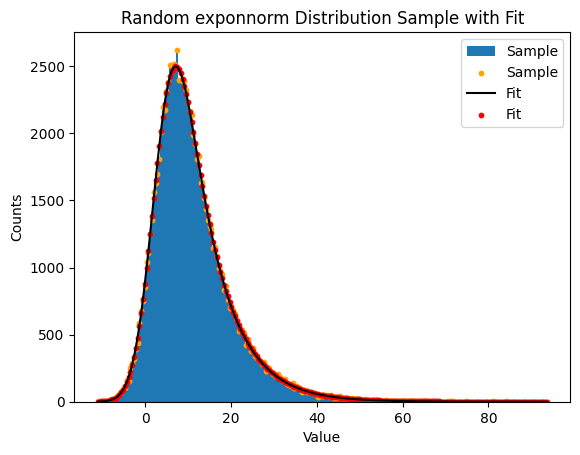

Original parameters: {'K': 2, 'loc': 3, 'scale': 4}
Fit parameters: (np.float64(1.9989499693325037), np.float64(3.0038167325285636), np.float64(4.00010103067298))


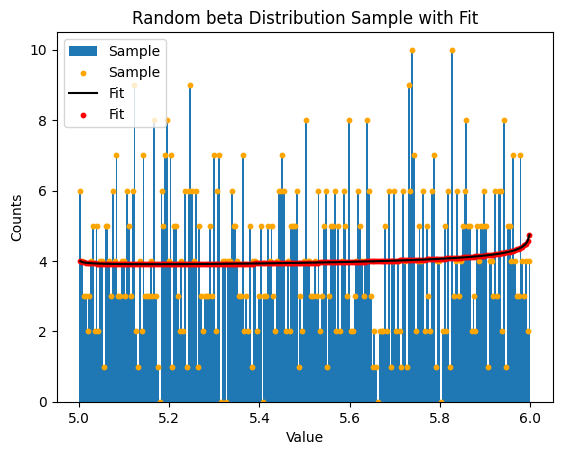

Original parameters: {'a': 1, 'b': 1, 'loc': 5, 'scale': 1}
Fit parameters: (np.float64(0.9934235915488714), np.float64(0.9659465405017283), np.float64(5.001207885935409), np.float64(0.9986796429945973))


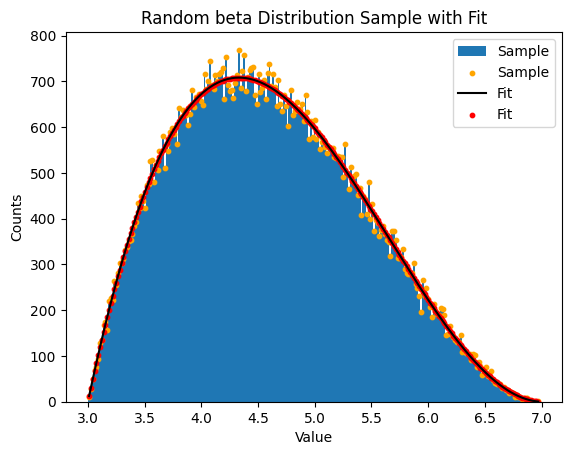

Original parameters: {'a': 2, 'b': 3, 'loc': 3, 'scale': 4}
Fit parameters: (np.float64(2.007831367533334), np.float64(3.025338676391656), np.float64(2.999152688204355), np.float64(4.011076270043018))


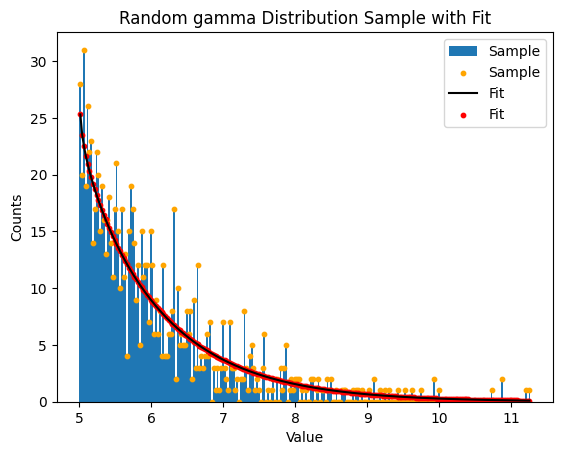

Original parameters: {'a': 1, 'loc': 5, 'scale': 1}
Fit parameters: (np.float64(0.953273952629156), np.float64(5.000406918908429), np.float64(1.1781093291164528))


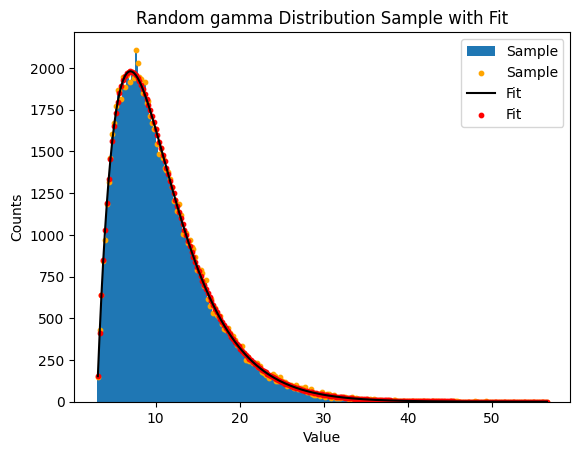

Original parameters: {'a': 2, 'loc': 3, 'scale': 4}
Fit parameters: (np.float64(2.0011846016216044), np.float64(3.0062859941124787), np.float64(3.985742735805916))


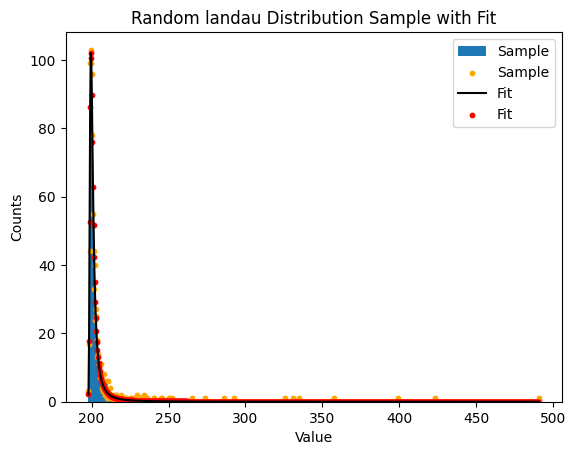

Original parameters: {'loc': 200, 'scale': 1}
Fit parameters: (np.float64(200.01245521150295), np.float64(1.008604986060067))


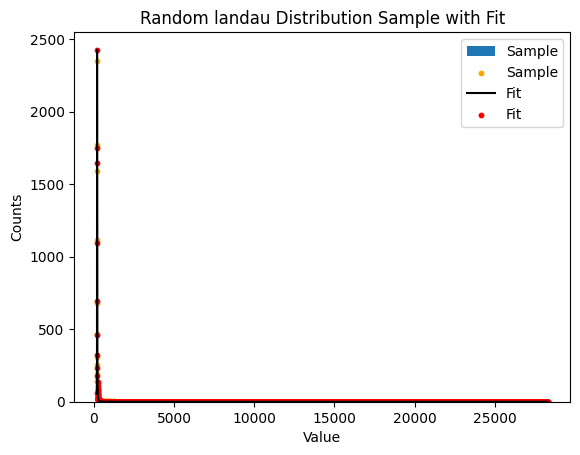

Original parameters: {'loc': 200, 'scale': 4}
Fit parameters: (np.float64(200.09503873806807), np.float64(4.054178942570356))


In [4]:
def generate_random_data(distribution, size=1000, n_bins = 250, **kwargs):
   '''
   Samples, fits, and plots random data from a distribution in scipy.stats
   '''
   plt.title(f"Random {distribution.name} Distribution Sample with Fit")
   plt.xlabel("Value")
   plt.ylabel("Counts")

   samp = distribution.rvs(size=size, **kwargs)
   n,bins,patches = plt.hist(samp, bins=n_bins, label="Sample")
   x = (bins[:-1] + bins[1:]) / 2
   y = n
   plt.scatter(x, y, label="Sample", s=10, color="orange")

   fit_param = distribution.fit(samp)
   fit = distribution.pdf(x, *fit_param) * len(samp) * (max(samp)-min(samp))/n_bins
   plt.plot(x, fit, label="Fit", color = "black")
   plt.scatter(x, fit, label="Fit", s=10, color = "red")

   plt.legend()
   plt.show()
   print(f"Original parameters: {kwargs}")
   print(f"Fit parameters: {fit_param}")
   return samp, x, y, fit

names = ["norm1","norm2","exponnorm1","exponnorm2","beta1","beta2","gamma1","gamma2","landau1","landau2"]

random_samples=[]
random_samples.append(generate_random_data(norm, loc=5, scale=1, size=1000))
random_samples.append(generate_random_data(norm, loc=3, scale=4, size=100000))
random_samples.append(generate_random_data(exponnorm, K=1, loc=5, scale=1, size=1000))
random_samples.append(generate_random_data(exponnorm, K=2, loc=3, scale=4, size=100000))
random_samples.append(generate_random_data(beta, a=1, b=1, loc=5, scale=1, size=1000))
random_samples.append(generate_random_data(beta, a=2, b=3, loc=3, scale=4, size=100000))
random_samples.append(generate_random_data(gamma, a=1, loc=5, scale=1, size=1000))
random_samples.append(generate_random_data(gamma, a=2, loc=3, scale=4, size=100000))
random_samples.append(generate_random_data(landau, loc=200, scale=1, size=1000, n_bins = 800))
random_samples.append(generate_random_data(landau, loc=200, scale=4, size=10000, n_bins = 8000))

### Fixing $\chi^2$

In [5]:
from scipy.interpolate import interp1d, make_interp_spline

for i in range(len(random_samples)):
   samp, x, y, fit = random_samples[i]
   cdf = lambda xi : make_interp_spline(x, pdf2cdf(fit, x), 5)(xi)
   print(f"{names[i]:7} Chi-Squared test:", chi_squared(samp, cdf))

print("\n")

# Manually calculated chi-squared for norm1
samp, x, y, fit = random_samples[0]
chi2_stat = np.sum((y - fit)**2 / fit)
df = len(x) - 1 - 2 # Number of bins - 1 - number of parameters estimated from data
print(f"norm1    Chi-Squared Test (manual): {chi2_stat}, Degrees of Freedom: {df}")
print(f"norm1    p-value (manual): {1 - chi2.cdf(chi2_stat, df)}")

print("\n")

# Manyally inputted n_params chi_squared
samp, x, y, fit = random_samples[0]
cdf = lambda xi : make_interp_spline(x, pdf2cdf(fit, x), 5)(xi)
print(f"norm1    Chi-Squared test (manually inputted n_params):", chi_squared(samp, cdf, n_params=2)[0])
print(f"norm1    p-value (manually inputted n_params): {chi_squared(samp, cdf, n_params=2)[1]}")

Number of parameters: 0
norm1   Chi-Squared test: (np.float64(-1721.5671223912145), np.float64(nan))
Number of parameters: 0
norm2   Chi-Squared test: (np.float64(-287878.5891571726), np.float64(nan))
Number of parameters: 0
exponnorm1 Chi-Squared test: (np.float64(-1526.1894443276794), np.float64(nan))
Number of parameters: 0
exponnorm2 Chi-Squared test: (np.float64(362109.00963869644), np.float64(0.0))
Number of parameters: 0
beta1   Chi-Squared test: (np.float64(-3208.8822077141053), np.float64(nan))
Number of parameters: 0
beta2   Chi-Squared test: (np.float64(-132533.95440257946), np.float64(nan))
Number of parameters: 0
gamma1  Chi-Squared test: (np.float64(81.98091749555454), np.float64(3.3714876460211204e-07))
Number of parameters: 0
gamma2  Chi-Squared test: (np.float64(61621.70648262098), np.float64(0.0))
Number of parameters: 0
landau1 Chi-Squared test: (np.float64(-641.4684968061812), np.float64(nan))
Number of parameters: 0
landau2 Chi-Squared test: (np.float64(238809.4535

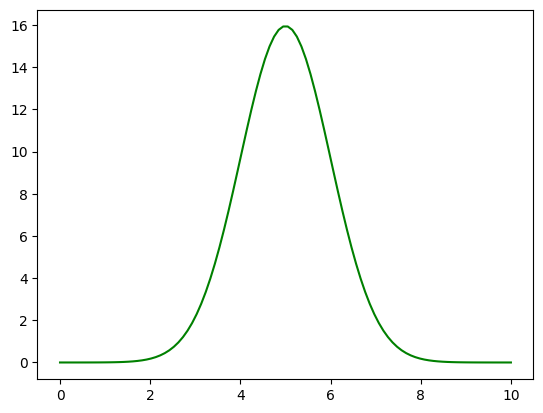

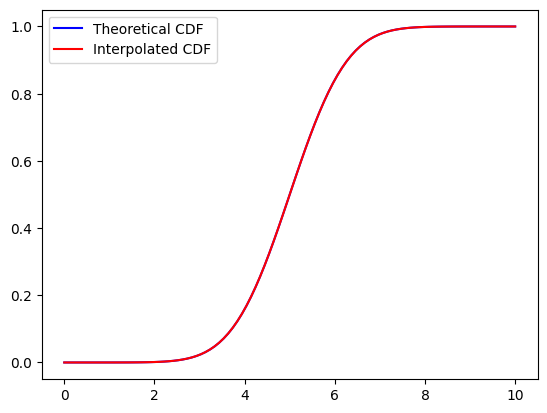

In [6]:
def pdf2cdf2(x,y_pdf):
   '''
   Given a set of x,y_pdf values which make up a pdf, 
   returns the y_cdf values which correspond to the cdf of that distribution with the same x values
   '''
   dx = np.diff(x)
   # print(len(x),len(dx),len(y_pdf))
   y_cdf = np.empty_like(y_pdf)
   y_cdf[0] = 0
   y_cdf[1:] = np.cumsum((y_pdf[:-1] + y_pdf[1:]) / 2 * dx)
   return y_cdf / y_cdf[-1]

x = np.linspace(0, 10, 100)
y_pdf = norm.pdf(x, loc=5, scale=1) * 1000 * (max(x)-min(x))/250
plt.plot(x, y_pdf, label="Theoretical PDF", color="green")
plt.show()

y_cdf_actual = norm.cdf(x, loc=5, scale=1)
plt.plot(x, y_cdf_actual, label="Theoretical CDF", color="blue")
# print(len(fit),len(x))
cdf = lambda xi : make_interp_spline(x, pdf2cdf2(x, y_pdf), 5)(xi)
y_cdf_interpolated = [cdf(xi) for xi in x]
plt.plot(x, y_cdf_interpolated, label="Interpolated CDF", color="red")
plt.legend()
plt.show()

In [7]:
from scipy.interpolate import interp1d, make_interp_spline

for i in range(len(random_samples)):
   samp, x, y, fit = random_samples[i]
   cdf = lambda xi : make_interp_spline(x, pdf2cdf2(x,fit), 5)(xi)
   print(f"{names[i]:7} Chi-Squared test:", chi_squared(samp, cdf))

print("\n")

# Manually calculated chi-squared for norm1
samp, x, y, fit = random_samples[0]
chi2_stat = np.sum((y - fit)**2 / fit)
df = len(x) - 1 - 2 # Number of bins - 1 - number of parameters estimated from data
print(f"norm1    Chi-Squared Test (manual): {chi2_stat}, Degrees of Freedom: {df}")
print(f"norm1    p-value (manual): {1 - chi2.cdf(chi2_stat, df)}")

print("\n")

# Manually inputted n_params chi_squared
samp, x, y, fit = random_samples[0]
cdf = lambda xi : make_interp_spline(x, pdf2cdf2(x,fit), 5)(xi)
print(f"norm1    Chi-Squared test (manually inputted n_params):", chi_squared(samp, cdf, n_params=2)[0])
print(f"norm1    p-value (manually inputted n_params): {chi_squared(samp, cdf, n_params=2)[1]}")

# Automatically Calculated n_params chi_squared
samp, x, y, fit = random_samples[0]
cdf = lambda xi : make_interp_spline(x, pdf2cdf2(x,fit), 5)(xi)
print(f"norm1    Chi-Squared test (manually inputted n_params):", chi_squared(samp, cdf)[0])
print(f"norm1    p-value (manually inputted n_params): {chi_squared(samp, cdf, n_params=2)[1]}")

Number of parameters: 0
norm1   Chi-Squared test: (np.float64(18.869404963325874), np.float64(0.8033389040398171))
Number of parameters: 0
norm2   Chi-Squared test: (np.float64(162.73288678830664), np.float64(0.09165649635841698))
Number of parameters: 0
exponnorm1 Chi-Squared test: (np.float64(45.80123358218217), np.float64(0.10458380291107981))
Number of parameters: 0
exponnorm2 Chi-Squared test: (np.float64(260.88219948593076), np.float64(0.19296007276299884))
Number of parameters: 0
beta1   Chi-Squared test: (np.float64(5.262567146771024), np.float64(0.8108452521730171))
Number of parameters: 0
beta2   Chi-Squared test: (np.float64(87.47743900080773), np.float64(0.1732811938365153))
Number of parameters: 0
gamma1  Chi-Squared test: (np.float64(25.86791255563337), np.float64(0.5803049888561275))
Number of parameters: 0
gamma2  Chi-Squared test: (np.float64(188.73577825687897), np.float64(0.2943932835573498))
Number of parameters: 0
landau1 Chi-Squared test: (np.float64(743.146052665

In [8]:
print(cdf.__code__.co_varnames)

('xi',)


Is this because of really far, stray events blowing up $\chi^2$?

In [ ]:
def chi_squared2(data, fit_cdf, n_params=None):
   '''
   Performs a Chi-Squared test to compare the empirical distribution of the data with the fitted distribution.
   Returns the Chi-Squared statistic and p-value.
   '''
   n, bins = np.histogram(data, bins="fd", density=False)
   if n_params is None:
      n_params = len(fit_cdf.__code__.co_varnames) - 1 # Double check these make sense
   print(f"Number of parameters: {n_params}")
   expected_probs = fit_cdf(bins[1:]) - fit_cdf(bins[:-1])

   # Remove really small expected values to avoid issues with the chi-squared test
   mask = expected_probs > 1e-6
   n = n[mask]
   expected_probs = expected_probs[mask]

   # Normalize`
   expected_probs /= np.sum(expected_probs)
   expected = np.sum(n) * expected_probs

   ret = chisquare(n,f_exp=expected,ddof=n_params)
   return ret.statistic, ret.pvalue

for i in range(len(random_samples)):
   samp, x, y, fit = random_samples[i]
   cdf = lambda xi : make_interp_spline(x, pdf2cdf2(x,fit), 5)(xi)
   print(f"{names[i]:7} Chi-Squared test v1:", chi_squared(samp, cdf), "v2:", chi_squared2(samp, cdf))

Number of parameters: 0
Number of parameters: 0
norm1   Chi-Squared test v1: (np.float64(18.869404963325874), np.float64(0.8033389040398171)) v2: (np.float64(18.869404963325874), np.float64(0.8033389040398171))
Number of parameters: 0
Number of parameters: 0
norm2   Chi-Squared test v1: (np.float64(162.73288678830664), np.float64(0.09165649635841698)) v2: (np.float64(162.73288678830664), np.float64(0.09165649635841698))
Number of parameters: 0
Number of parameters: 0
exponnorm1 Chi-Squared test v1: (np.float64(45.80123358218217), np.float64(0.10458380291107981)) v2: (np.float64(45.80123358218217), np.float64(0.10458380291107981))
Number of parameters: 0
Number of parameters: 0
exponnorm2 Chi-Squared test v1: (np.float64(260.88219948593076), np.float64(0.19296007276299884)) v2: (np.float64(248.7027166187861), np.float64(0.2725649401171947))
Number of parameters: 0
Number of parameters: 0
beta1   Chi-Squared test v1: (np.float64(5.262567146771024), np.float64(0.8108452521730171)) v2: (np

### Fixing KS Test

In [ ]:
from scipy.interpolate import interp1d, make_interp_spline

for i in range(len(random_samples)):
   samp, x, y, fit = random_samples[i]
   cdf = lambda xi : make_interp_spline(x, pdf2cdf(x, fit), 5)(xi)
   print(f"{names[i]:7} Kolmogorov-Smirnov test:", kolmogorov_smirnov(samp, cdf))

norm1   Kolmogorov-Smirnov test: (np.float64(0.012624865319574186), np.float64(0.996725510492934))
norm2   Kolmogorov-Smirnov test: (np.float64(0.0013728878602299321), np.float64(0.9915832372640165))
exponnorm1 Kolmogorov-Smirnov test: (np.float64(0.012965132139855173), np.float64(0.9953064715406185))
exponnorm2 Kolmogorov-Smirnov test: (np.float64(0.0017307921561009465), np.float64(0.9249592990495183))
beta1   Kolmogorov-Smirnov test: (np.float64(0.03333179361537364), np.float64(0.21175280381376937))
beta2   Kolmogorov-Smirnov test: (np.float64(0.002463128605667775), np.float64(0.5779328678306632))
gamma1  Kolmogorov-Smirnov test: (np.float64(0.06396175458332198), np.float64(0.0005327868120476348))
gamma2  Kolmogorov-Smirnov test: (np.float64(0.0035163032685278095), np.float64(0.1681881550346268))
landau1 Kolmogorov-Smirnov test: (np.float64(0.1312423067403735), np.float64(1.7674190122944558e-15))
landau2 Kolmogorov-Smirnov test: (np.float64(0.010971860838687467), np.float64(0.1786142

### Fixing Anderson-Darling Test

In [ ]:
from scipy.interpolate import interp1d, make_interp_spline

for i in range(len(random_samples)):
   samp, x, y, fit = random_samples[i]
   cdf = lambda xi : make_interp_spline(x, pdf2cdf(x, fit), 5)(xi)
   print(f"{names[i]:7} Anderson-Darling test:", anderson_darling(samp, cdf))

/var/folders/mp/wxx05wqx5tz5qykh9r4x9c4c0000gn/T/ipykernel_23394/515028742.py:20: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  ret = anderson_ksamp([data, fit_cdf(np.sort(data))])
/var/folders/mp/wxx05wqx5tz5qykh9r4x9c4c0000gn/T/ipykernel_23394/515028742.py:20: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ret = anderson_ksamp([data, fit_cdf(np.sort(data))])


norm1   Anderson-Darling test: (np.float64(1014.5103714689983), np.float64(0.001))
norm2   Anderson-Darling test: (np.float64(41278.40328338982), np.float64(0.001))
exponnorm1 Anderson-Darling test: (np.float64(1014.5103714689983), np.float64(0.001))
exponnorm2 Anderson-Darling test: (np.float64(80991.32246544471), np.float64(0.001))
beta1   Anderson-Darling test: (np.float64(1014.5103714689983), np.float64(0.001))
beta2   Anderson-Darling test: (np.float64(101468.76648800679), np.float64(0.001))
gamma1  Anderson-Darling test: (np.float64(1014.5103714689983), np.float64(0.001))
gamma2  Anderson-Darling test: (np.float64(101468.76648800679), np.float64(0.001))
landau1 Anderson-Darling test: (np.float64(1014.5103714689983), np.float64(0.001))
landau2 Anderson-Darling test: (np.float64(10146.718745227683), np.float64(0.001))
